# INN Hotels - Booking Cancellation Prediction

## Objective: Predict whether a hotel booking will be cancelled so the hotel can take pre-emptive action.

In [1]:
#Importing all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

## Importing necessary libraries

## Loading the dataset

In [2]:
#Read the dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\INNHotelsGroup.csv")

## Data Overview

In [3]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [4]:
df.shape

(36275, 19)

In [5]:
#There are 36275 rows and 19 columns in this dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [7]:
#There are 14 numerical features & 5 categorical features.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


In [9]:
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

## Exploratory Data Analysis (EDA)

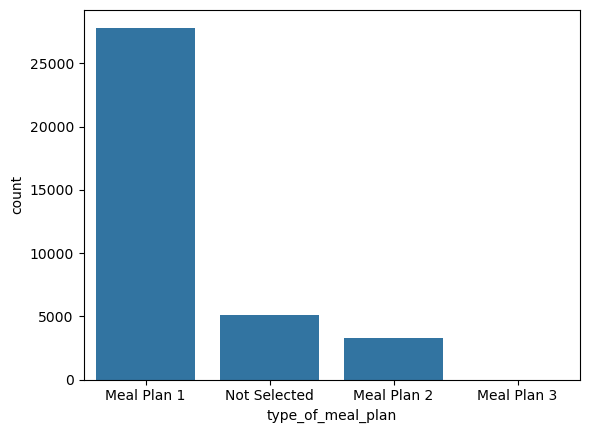

In [10]:
#Categorical variables - Bar plots / count plots
sns.countplot(x='type_of_meal_plan', data=df)
plt.show()
#'Meal Plan 1' is the most popular meal plan among hotel guests.

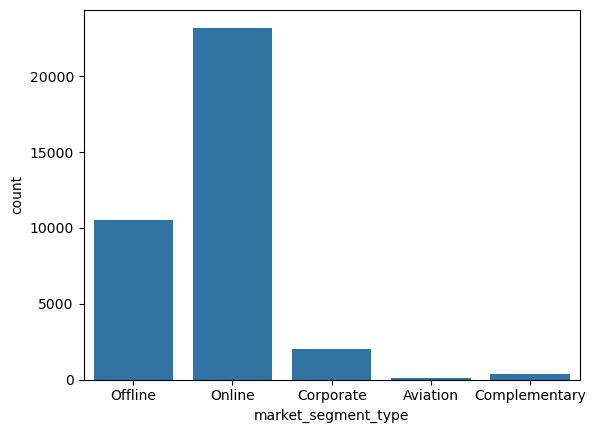

In [11]:
sns.countplot(x='market_segment_type', data=df)
plt.show()
#Online is the most common market segment for bookings.

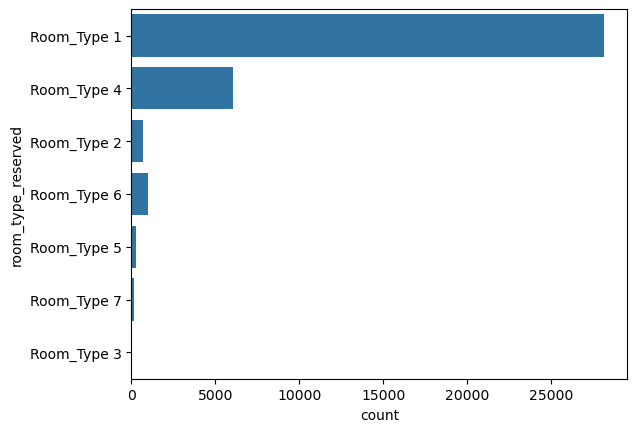

In [12]:
sns.countplot(y='room_type_reserved', data=df)
plt.show()
#Room_Type 1 is the most frequently booked room type.

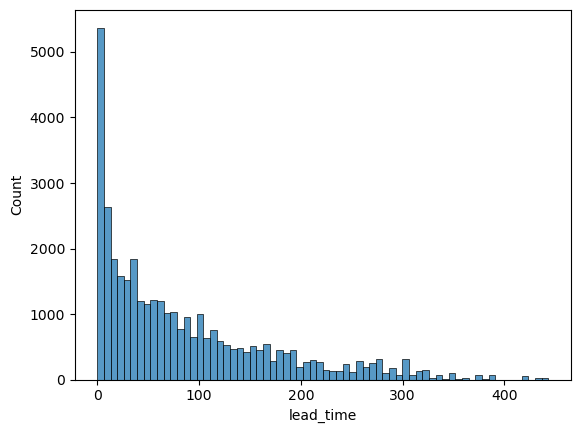

In [13]:
#Numerical variables - Histograms
sns.histplot(x='lead_time', data=df)
plt.show()
#Right-skewed distribution - most bookings have shorter lead times.

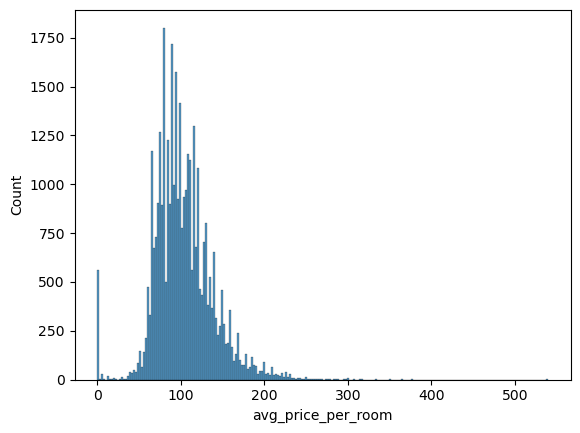

In [14]:
sns.histplot(x='avg_price_per_room', data=df)
plt.show()
#Right-skewed - most prices are concentrated around a typical range.

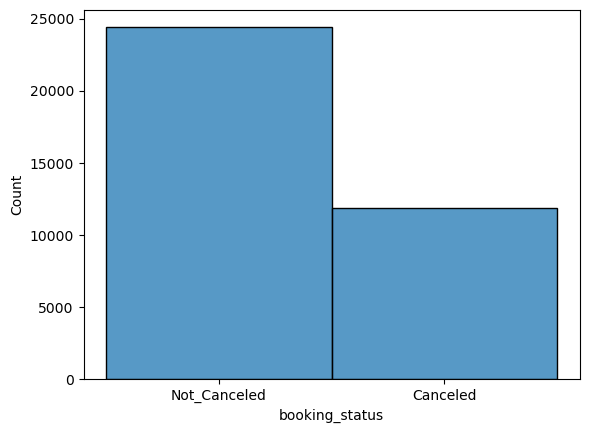

In [15]:
sns.histplot(x='booking_status', data=df)
plt.show()
#Shows frequency of Canceled vs Not_Canceled bookings.

## Bivariate Analysis

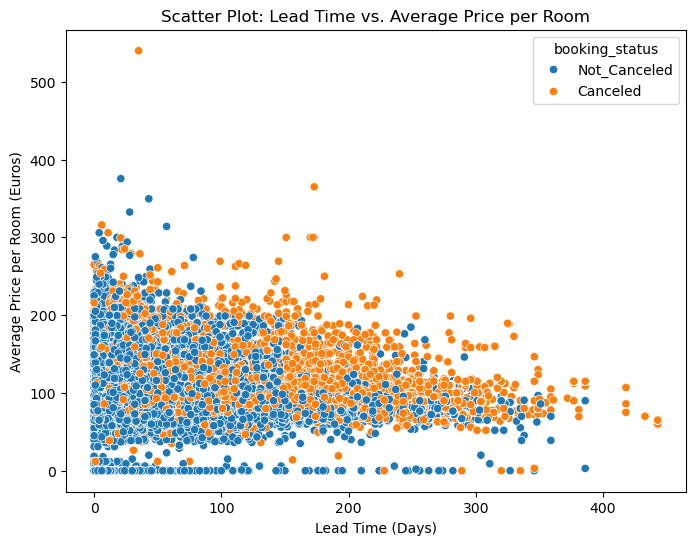

In [16]:
#Scatter plot: Lead Time vs Average Price per Room
plt.figure(figsize=(8, 6))
sns.scatterplot(x='lead_time', y='avg_price_per_room', data=df, hue='booking_status')
plt.title('Scatter Plot: Lead Time vs. Average Price per Room')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Average Price per Room (Euros)')
plt.show()
#Bookings with longer lead times show higher cancellation tendency.

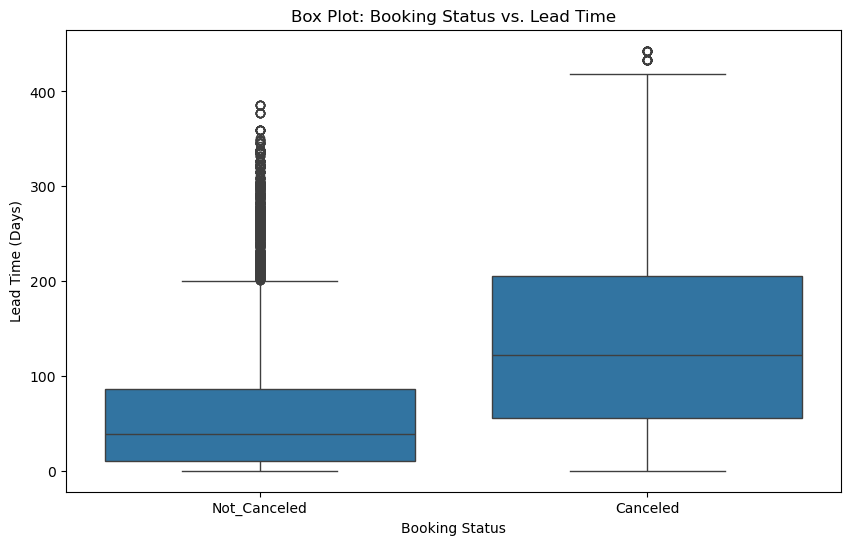

In [17]:
#Box plot: Booking Status vs Lead Time
plt.figure(figsize=(10, 6))
sns.boxplot(x='booking_status', y='lead_time', data=df)
plt.title('Box Plot: Booking Status vs. Lead Time')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (Days)')
plt.show()
#Canceled bookings generally have longer lead times than non-canceled ones.

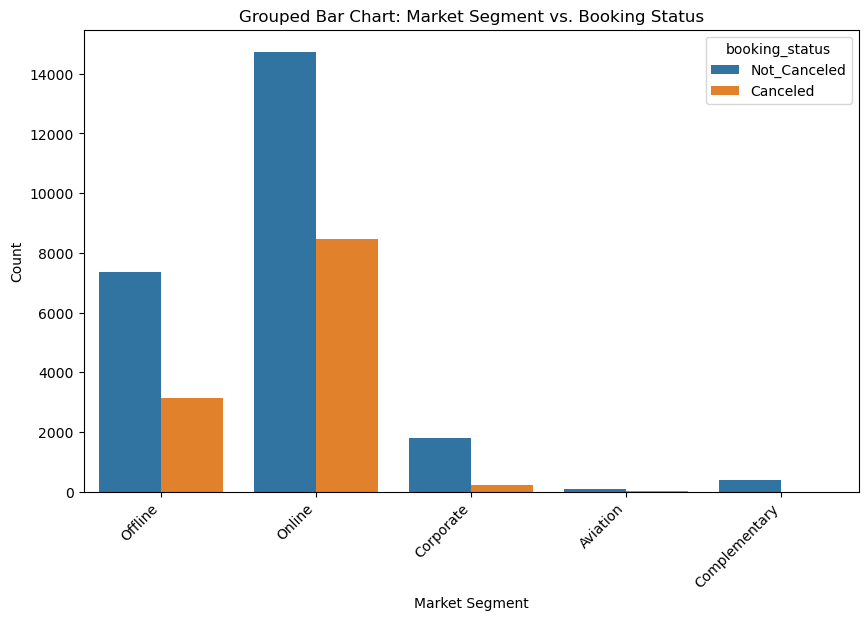

In [18]:
#Grouped bar chart: Market Segment vs Booking Status
plt.figure(figsize=(10, 6))
sns.countplot(x='market_segment_type', hue='booking_status', data=df)
plt.title('Grouped Bar Chart: Market Segment vs. Booking Status')
plt.xlabel('Market Segment')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()
#Online TA segment has a higher proportion of canceled bookings.

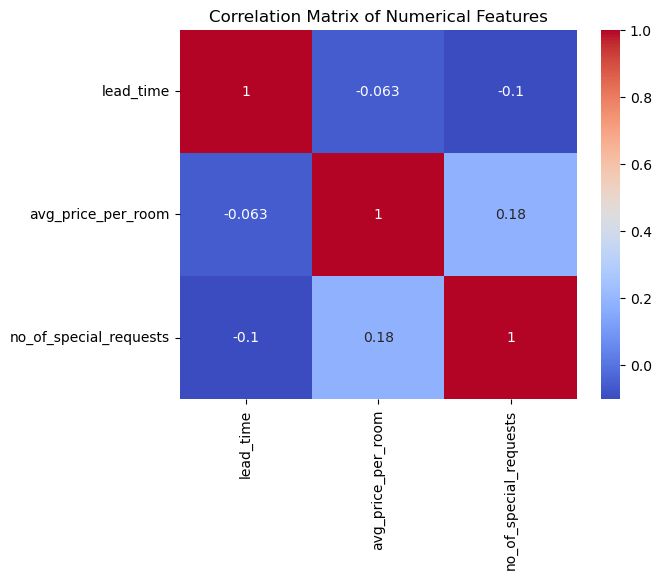

In [19]:
#Correlation heatmap for key numerical features
numerical_features = ['lead_time', 'avg_price_per_room', 'no_of_special_requests']
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

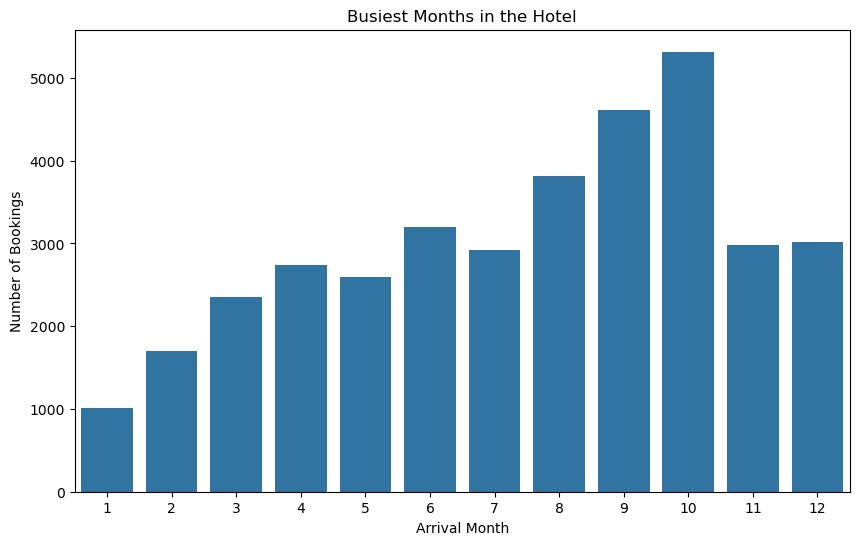

In [20]:
#Group bookings by arrival month to find busiest months
bookings_by_month = df.groupby('arrival_month')['Booking_ID'].count().reset_index()
bookings_by_month.rename(columns={'Booking_ID': 'Number of Bookings'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='arrival_month', y='Number of Bookings', data=bookings_by_month)
plt.title('Busiest Months in the Hotel')
plt.xlabel('Arrival Month')
plt.ylabel('Number of Bookings')
plt.show()
#October is the busiest month; January and February are the slowest.

The most common market segment is: Online


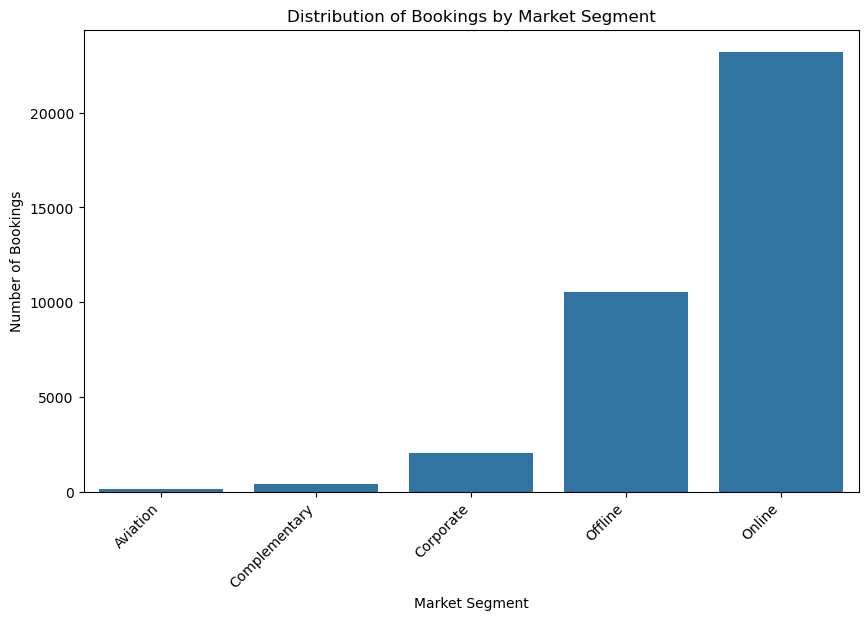

In [21]:
#Group and count bookings by market segment
market_segment_counts = df.groupby('market_segment_type')['Booking_ID'].count().reset_index()
market_segment_counts.rename(columns={'Booking_ID': 'Number of Bookings'}, inplace=True)

#Find the market segment with the most bookings
most_common_segment = market_segment_counts.loc[market_segment_counts['Number of Bookings'].idxmax()]
print(f"The most common market segment is: {most_common_segment['market_segment_type']}")

plt.figure(figsize=(10, 6))
sns.barplot(x='market_segment_type', y='Number of Bookings', data=market_segment_counts)
plt.title('Distribution of Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.show()
#Online segment has the most bookings.

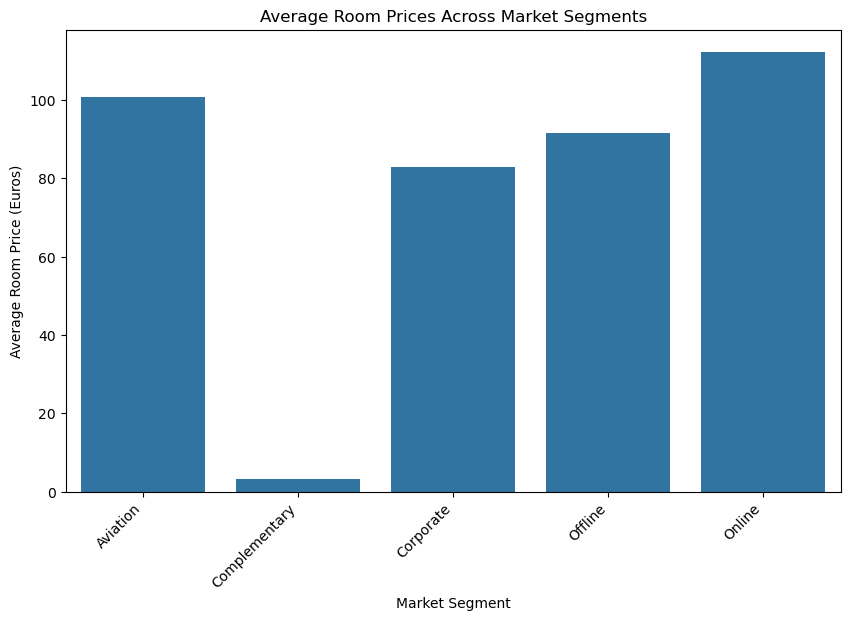

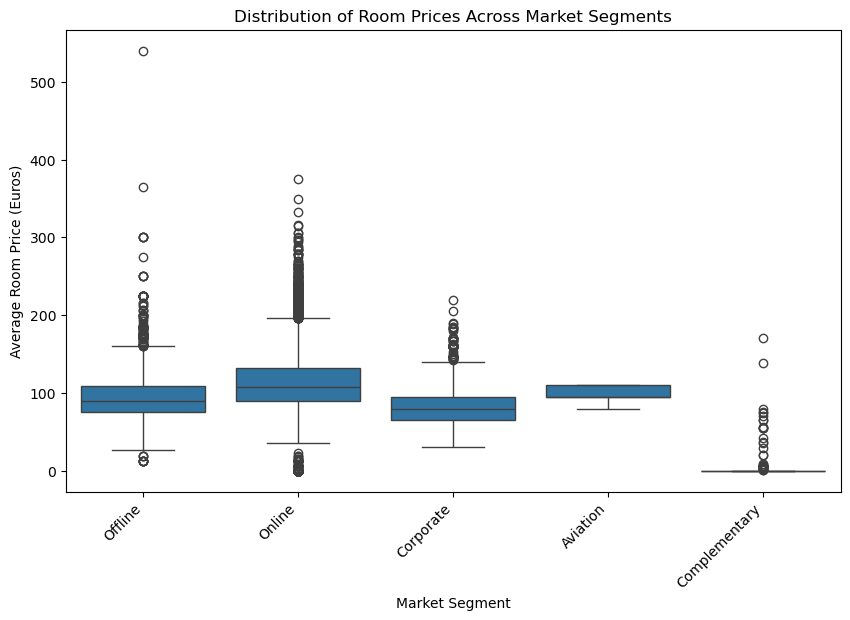

In [22]:
#Average room prices per market segment
avg_prices_by_segment = df.groupby('market_segment_type')['avg_price_per_room'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='market_segment_type', y='avg_price_per_room', data=avg_prices_by_segment)
plt.title('Average Room Prices Across Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Average Room Price (Euros)')
plt.xticks(rotation=45, ha='right')
plt.show()

#Box plots: distribution of room prices within each market segment
plt.figure(figsize=(10, 6))
sns.boxplot(x='market_segment_type', y='avg_price_per_room', data=df)
plt.title('Distribution of Room Prices Across Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Average Room Price (Euros)')
plt.xticks(rotation=45, ha='right')
plt.show()
#Groups segment has the lowest and least variable room prices.

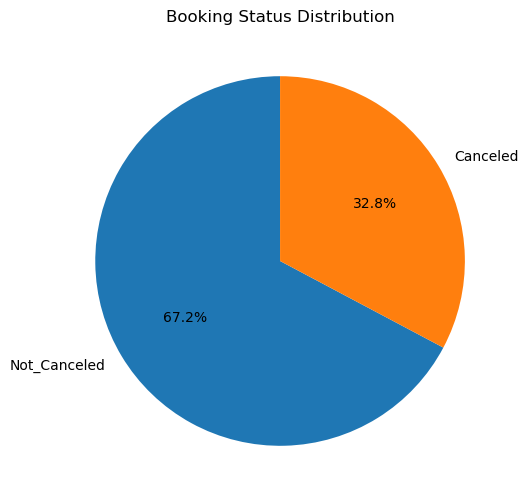

In [23]:
#Booking status distribution - pie chart
booking_status_counts = df['booking_status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(booking_status_counts, labels=booking_status_counts.index,
        autopct='%1.1f%%', startangle=90)
plt.title('Booking Status Distribution')
plt.show()
#32.8% of bookings are cancelled.

Percentage of repeating guests who cancel: 1.72%


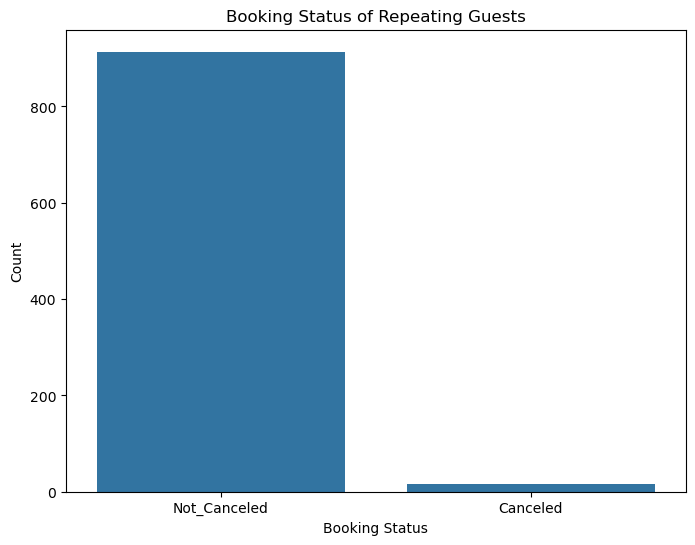

In [24]:
#Repeating guests cancellation analysis
repeating_guests = df[df['repeated_guest'] == 1]

total_repeating_guests = len(repeating_guests)
canceled_repeating_guests = repeating_guests['booking_status'].value_counts()['Canceled']
percentage_canceled_repeating = (canceled_repeating_guests / total_repeating_guests) * 100
print(f"Percentage of repeating guests who cancel: {percentage_canceled_repeating:.2f}%")

plt.figure(figsize=(8, 6))
sns.countplot(x='booking_status', data=repeating_guests)
plt.title('Booking Status of Repeating Guests')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.show()
#Only 1.72% of repeating guests cancel their bookings.

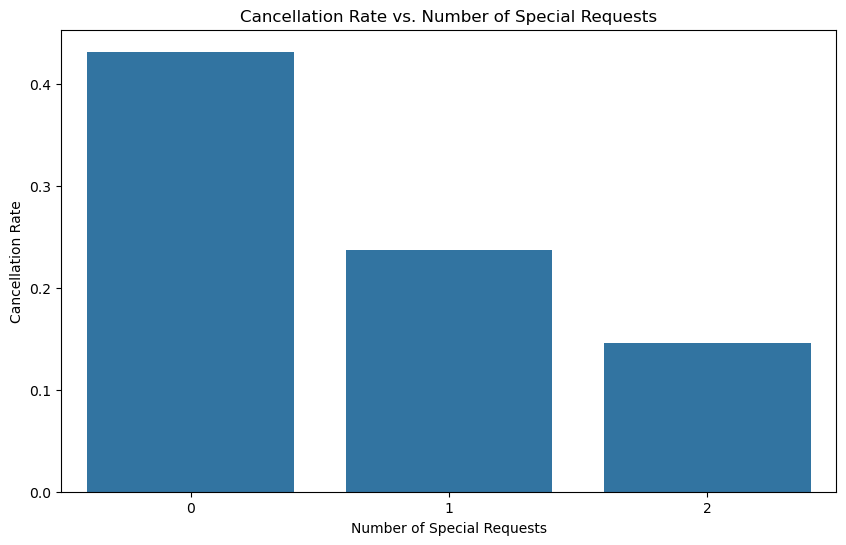

In [25]:
#Impact of special requests on cancellation rate
special_requests_impact = df.groupby(['no_of_special_requests', 'booking_status'])['Booking_ID'].count().reset_index()
special_requests_impact.rename(columns={'Booking_ID': 'count'}, inplace=True)

special_requests_impact['cancellation_rate'] = special_requests_impact.groupby('no_of_special_requests')['count'].transform(
    lambda x: x / x.sum()
)

special_requests_cancellation_rates = special_requests_impact[
    special_requests_impact['booking_status'] == 'Canceled'
]

plt.figure(figsize=(10, 6))
sns.barplot(x='no_of_special_requests', y='cancellation_rate',
            data=special_requests_cancellation_rates)
plt.title('Cancellation Rate vs. Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate')
plt.show()
#Guests with more special requests are less likely to cancel.

## Data Preprocessing

In [26]:
#Check for missing values
df.isnull().sum()
#No missing values found in the dataset.

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [27]:
#Scale numerical features using StandardScaler
numerical_features = ['lead_time', 'avg_price_per_room', 'no_of_special_requests', 'no_of_weekend_nights', 'no_of_week_nights']

scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

#Drop Booking_ID as it does not contribute to prediction
X = df.drop(['booking_status', 'Booking_ID'], axis=1)
y = df['booking_status']

In [28]:
#One-hot encoding for categorical features
categorical_features = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type',
                        'required_car_parking_space', 'repeated_guest']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [29]:
#Train-test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit and transform the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (29020, 32)
X_test shape: (7255, 32)


## Model Building

In [30]:
#Encode target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [31]:
#Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")

Logistic Regression:
  Accuracy  : 0.8015
  Precision : 0.8255
  Recall    : 0.8907
  F1 Score  : 0.8569


In [32]:
#KNN Classifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN Classifier:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_knn):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_knn):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_knn):.4f}")

  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py",

KNN Classifier:
  Accuracy  : 0.8433
  Precision : 0.8664
  Recall    : 0.9045
  F1 Score  : 0.8850


In [33]:
#Naive Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Classifier:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_nb):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_nb):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_nb):.4f}")

Naive Bayes Classifier:
  Accuracy  : 0.4085
  Precision : 0.8774
  Recall    : 0.1316
  F1 Score  : 0.2289


In [34]:
#SVM Classifier
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Classifier:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_svm):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_svm):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_svm):.4f}")

SVM Classifier:
  Accuracy  : 0.6670
  Precision : 0.6670
  Recall    : 1.0000
  F1 Score  : 0.8002


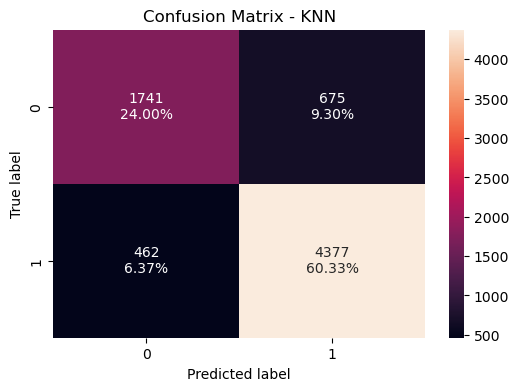

In [35]:
#Confusion matrix for best model (KNN)
cm = confusion_matrix(y_test, y_pred_knn)
labels = np.asarray(
    [["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
     for item in cm.flatten()]
).reshape(2, 2)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=labels, fmt="")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix - KNN")
plt.show()

In [36]:
#Final model comparison table
models_comp_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Naive Bayes', 'SVM'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_knn),
                  accuracy_score(y_test, y_pred_nb),
                  accuracy_score(y_test, y_pred_svm)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_knn),
                  precision_score(y_test, y_pred_nb),
                  precision_score(y_test, y_pred_svm)],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_knn),
                  recall_score(y_test, y_pred_nb),
                  recall_score(y_test, y_pred_svm)],
    'F1 Score':  [f1_score(y_test, y_pred_lr),
                  f1_score(y_test, y_pred_knn),
                  f1_score(y_test, y_pred_nb),
                  f1_score(y_test, y_pred_svm)],
})

print("Model Performance Comparison:")
models_comp_df
#KNN Classifier shows the best overall performance with highest accuracy, precision, recall and F1.

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.801516,0.825512,0.890680,0.856859
1,KNN,0.843280,0.866390,0.904526,0.885047
2,Naive Bayes,0.408546,0.877410,0.131639,0.228931
3,SVM,0.666988,0.666988,1.000000,0.800232


## Conclusion: KNN delivered the best performance among Logistic Regression, KNN, Naive Bayes, and SVM. Longer lead times and online bookings were key cancellation signals.